# Options on a Cointegrated Spread: Pricing and Regime-Aware Hedging of a Pairs Trade

**Erdős Institute - Introduction to Quantitative Methods in Finance, Summer 2026**

**Team:** *Sara Mezuri*

---

## Project overview

The classic pairs trade holds a long/short position in shares of two cointegrated stocks and bets that their spread mean-reverts. In this project we instead express and manage the trade with **options on the spread**, which creates three quantitative challenges that map directly onto the course:

1. **No closed form.** A European spread option with payoff $\max(S_1(T) - h S_2(T) - K,\, 0)$ has **no Black–Scholes closed-form price for $K \neq 0$**. Both $S_1(T)$ and $S_2(T)$ are lognormal, but the difference of two lognormal random variables is not lognormal. So when we write down the pricing integral $$V = e^{-rT}\iint \max(S_1 - hS_2 - K,\, 0)\, f(s_1, s_2)\, ds_1\, ds_2,$$ we can't solve it symbolically. The integral is perfectly well-defined, there's just no formula for it. However, the price exists and is a specific number. We must price it by Monte Carlo on *correlated* GBM paths.

2. **A perfect control variate exists.**  When $K = 0$, the payoff is $\max(S_1 - hS_2, 0) = S_2 \max(S_1/S_2 - 1, 0)$. We can factor out $S_2$​ and the payoff now depends on the ratio $S_1/S_2$, and the ratio of lognormals is lognormal. Measured in units of $S_2$​, the problem becomes a one-dimensional lognormal problem, which is just Black-Scholes again. Thus, for $K = 0$ the price *is* closed-form (the **Margrabe exchange option formula**). The $K=0$ option is highly correlated with the $K\neq 0$ option.

3. **Two-dimensional hedging & correlation risk.** The option has two deltas, one per leg. Correlation between the legs is the quantity that breaks down in market stress, which is exactly when pairs trades fail. We model this with a **2-state Markov regime-switching model** and compare constant-parameter Black–Scholes hedging against regime-aware hedging.

# 01 Pair Selection: Cointegration Screening, OU Fit, and Signals


**In this notebook.** Select a tradeable cointegrated pair using *training data only*, fit an Ornstein–Uhlenbeck model to its spread, verify parameter stability, and generate entry/exit signals on the out-of-sample window.

**Outputs.** The final cell prints a parameter block that is copy-pasted into the headers of notebooks 02–05, so every notebook runs independently.

In [41]:
# Imports and ALL parameters 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import adfuller, coint

TRADING_DAYS = 252
r_f = 0.04                      # flat risk-free rate 

# Data window and train/test split
DATA_START = "2021-01-01"
DATA_END   = "2026-07-01"
TRAIN_END  = "2024-07-01"       # train: 2021-01 .. 2024-06 | test: 2024-07 .. 2026-06

# Predetermined eligibility rule 
P_THRESHOLD        = 0.05       # Engle–Granger p-value
MIN_TRAIN_OBS      = 3 * TRADING_DAYS
MIN_HALF_LIFE_DAYS = 5          # faster than this: microstructure noise / untradeable
MAX_HALF_LIFE_DAYS = 126        # slower than this: option maturity becomes too long

# Trading rule 
Z_ENTRY, Z_EXIT = 2.0, 0.0

plt.rcParams["figure.figsize"] = (10, 5)


## 1.1 Cointegration and the Engle–Granger test

Two price series $S_1(t), S_2(t)$ are **cointegrated** if some linear combination

$$X(t) = \log S_1(t) - \alpha - \beta \log S_2(t)$$

is stationary even though each series individually is not. We use the
Engle–Granger two-step procedure:

1. Regress $\log S_1$ on $\log S_2$:
   $\;\log S_1(t) = \alpha + \beta \log S_2(t) + X(t)$ (OLS gives the hedge
   ratio $\hat\beta$).
2. Run a unit-root test on the residual $X(t)$. Because the residual comes
   from a *fitted* regression, we use Engle–Granger critical values
   (`statsmodels.tsa.stattools.coint`) rather than plain ADF ones; plain ADF
   is reported only as a cross-check.

Rejecting the unit-root null $\Rightarrow$ the spread is stationary
$\Rightarrow$ the pair is a candidate for trading.


In [42]:
def engle_granger(logp1: pd.Series, logp2: pd.Series):
    """Engle–Granger two-step cointegration test.
    """
    logp1, logp2 = logp1.align(logp2, join="inner")

    # Step 1: OLS hedge ratio
    beta, alpha = np.polyfit(logp2.values, logp1.values, deg=1)
    spread = logp1 - alpha - beta * logp2
    spread.name = "spread"

    # Step 2: residual unit-root tests
    eg_stat, eg_pvalue, _ = coint(logp1, logp2)          # correct EG critical values
    adf_stat, adf_pvalue, *_ = adfuller(spread.values)   # cross-check only

    tests = dict(eg_stat=eg_stat, eg_pvalue=eg_pvalue,
                 adf_stat=adf_stat, adf_pvalue=adf_pvalue)
    return beta, alpha, spread, tests


def fit_ou(spread: pd.Series, dt: float = 1 / TRADING_DAYS):
    """Fit OU parameters via the exact AR(1) discretization.
    """
    x = spread.values[:-1]
    y = spread.values[1:]

    b, a = np.polyfit(x, y, deg=1)

    if not (0.0 < b < 1.0):
        raise ValueError(
            f"AR(1) slope b = {b:.4f} is outside (0, 1): the spread is not "
            "mean-reverting in-sample."
        )

    resid = y - (a + b * x)
    s_eps = resid.std(ddof=2)                 # 2 fitted parameters

    kappa = -np.log(b) / dt                                  # per year
    theta = a / (1.0 - b)
    sigma_X = s_eps * np.sqrt(2.0 * kappa / (1.0 - b**2))    # b^2 = e^{-2 kappa dt}
    sigma_stat = sigma_X / np.sqrt(2.0 * kappa)
    half_life_days = np.log(2.0) / kappa * TRADING_DAYS

    return dict(kappa=kappa, theta=theta, sigma_X=sigma_X,
                half_life_days=half_life_days,
                sigma_stationary=sigma_stat, b=b, n_obs=len(x))


def estimate_gbm_params(prices: pd.DataFrame):
    """Annualized vols and log-return correlation from daily prices.
    """
    logret = np.log(prices).diff().dropna()
    sig = logret.std(ddof=1) * np.sqrt(TRADING_DAYS)
    rho = logret.iloc[:, 0].corr(logret.iloc[:, 1])
    return sig.iloc[0], sig.iloc[1], rho


## 1.2 Ornstein–Uhlenbeck model for the spread

We model the stationary spread as an OU process

$$dX_t = \kappa(\theta - X_t)\,dt + \sigma_X\, dW_t,$$

with mean-reversion speed $\kappa$, long-run mean $\theta$, and vol
$\sigma_X$. Exact discretization over step $\Delta t$:

$$X_{t+\Delta t} = \theta + (X_t - \theta)e^{-\kappa \Delta t} + \varepsilon_t,
\qquad
\varepsilon_t \sim N\!\Big(0,\; \tfrac{\sigma_X^2}{2\kappa}\big(1 - e^{-2\kappa \Delta t}\big)\Big).$$

This is an AR(1): regress $X_{t+\Delta t}$ on $X_t$, then recover

$$\kappa = -\frac{\ln b}{\Delta t}, \qquad
\theta = \frac{a}{1-b}, \qquad
\sigma_X = s_\varepsilon \sqrt{\frac{2\kappa}{1 - e^{-2\kappa\Delta t}}},$$

where $a, b$ are the AR(1) intercept/slope ($0 < b < 1$) and $s_\varepsilon$
the residual std. The half-life of a deviation is $t_{1/2} = \ln 2 / \kappa$
— this sets the natural option maturity $T$ for the trade. With
$\Delta t = 1/252$, $\kappa$ is annualized and $\ln 2/\kappa$ is in years
(multiply by 252 for days).

**Trading signal:** enter when the standardized spread
$z_t = (X_t - \theta)/\sigma_{X,\text{stat}}$ crosses $\pm 2$; exit at
$z_t = 0$ or after a maximum holding period of $2\times$ half-life. Here
$\sigma_{X,\text{stat}} = \sigma_X/\sqrt{2\kappa}$ is the stationary standard
deviation.

**Note on units.** The signal comes from the *log-price* spread $X_t$, but the
option (notebooks 02–05) pays on the *dollar* spread $S_1(T) - h S_2(T)$.
Because $\beta$ is a log-log elasticity, we convert it to a local dollar hedge
ratio $h = \beta\, S_1(0)/S_2(0)$ at each use.


In [43]:
def generate_signals(spread: pd.Series, ou: dict, z_entry=2.0, z_exit=0.0,
                     max_hold=None):
    """Entry/exit events from the standardized OU spread (train parameters).

    direction = +1: z < -z_entry, long spread
    direction = -1: z > +z_entry, short spread
    Exit when z crosses z_exit or after max_hold days.
    """
    z = (spread - ou["theta"]) / ou["sigma_stationary"]
    if max_hold is None:
        max_hold = int(round(2 * ou["half_life_days"]))

    trades, in_pos, d, e_idx = [], False, 0, None
    idx = z.index
    for i, zt in enumerate(z.values):
        if not in_pos:
            if zt < -z_entry:
                in_pos, d, e_idx = True, +1, i
            elif zt > z_entry:
                in_pos, d, e_idx = True, -1, i
        else:
            hit_exit = (d == +1 and zt >= z_exit) or (d == -1 and zt <= z_exit)
            timed_out = (i - e_idx) >= max_hold
            if hit_exit or timed_out or i == len(z) - 1:
                trades.append((idx[e_idx], idx[i], d, z.iloc[e_idx], zt))
                in_pos = False
    return pd.DataFrame(trades, columns=["entry_date", "exit_date",
                                         "direction", "z_at_entry", "z_at_exit"])


## 1.3 Candidate universe, controls, and the multiple-testing problem

We screen ~55 candidate pairs with a clear prior economic link (same sector,
similar business), plus two near-duplicate ETF pairs (SPY/IVV, GLD/IAU) as
**positive controls**, pairs that track the same underlying asset and should
show the strongest mean reversion the test can detect.

**Multiple testing.** Running ~55 tests at the 5% level means we expect ~3
"significant" pairs *even if no pair is truly cointegrated*. 

1. The eligibility rule (EG $p <$ 0.05, half-life between 5 and 126 trading days, $ \geq 3$y of data) is fixed **before** the screen is run.
2. Selection uses **training data only**.
3. The selected pair must have a clear economic rationale, not just a p-value.
4. Sub-window stability of $\hat\beta$ and the half-life is checked within the training window before the pair is accepted.

Even so, a residual risk of a false discovery remains; (this is one of the project's limitations.)

**Note on the controls.** The near-duplicate ETFs hold the same asset but have slightly different expense ratios, which puts a small deterministic drift in the log-spread. A constant-only Engle–Granger regression cannot distinguish that drift from a unit root, so the controls can *fail* the default test
despite being economically near-perfect pairs. We keep the constant-only specification and read the controls with this caveat in mind.

In [44]:
CONTROL_PAIRS = {
    ("GLD", "IAU"),   # two gold bullion ETFs
    ("SPY", "IVV"),   # two S&P 500 ETFs
}

CANDIDATES_FULL = [
    # country / index ETFs
    ("EWA", "EWC"), ("EWG", "EWQ"), ("EWU", "EWG"), ("EWT", "EWY"),
    # energy
    ("XOM", "CVX"), ("COP", "EOG"), ("SLB", "HAL"),
    ("VLO", "MPC"), ("KMI", "WMB"), ("ENB", "TRP"),
    # metals & miners
    ("GLD", "GDX"), ("GDX", "GDXJ"), ("GLD", "SLV"), ("AEM", "NEM"),
    # financials
    ("JPM", "BAC"), ("WFC", "C"), ("USB", "PNC"), ("GS", "MS"),
    ("RY", "TD"), ("BMO", "BNS"), ("MET", "PRU"), ("ALL", "PGR"),
    ("ICE", "CME"), ("V", "MA"), ("AXP", "COF"),
    # consumer
    ("KO", "PEP"), ("PG", "CL"), ("KMB", "CL"), ("GIS", "CAG"),
    ("MO", "PM"), ("MCD", "YUM"), ("WMT", "TGT"), ("TJX", "ROST"),
    ("DG", "DLTR"), ("HD", "LOW"), ("MAR", "HLT"), ("RCL", "CCL"),
    # industrials / transport
    ("UNP", "CSX"), ("CSX", "NSC"), ("UPS", "FDX"), ("DAL", "UAL"),
    ("LMT", "NOC"), ("CAT", "DE"), ("WM", "RSG"), ("GM", "F"),
    # healthcare
    ("PFE", "MRK"), ("ABT", "MDT"),
    # tech / semis
    ("TXN", "ADI"), ("AMAT", "LRCX"), ("KLAC", "LRCX"),
    # utilities / telecom / materials / REITs
    ("DUK", "SO"), ("AEP", "XEL"), ("T", "VZ"),
    ("LIN", "APD"), ("SHW", "PPG"), ("AMT", "CCI"), ("O", "NNN"),
]

SCREEN_LIST = sorted(CONTROL_PAIRS) + CANDIDATES_FULL

# one download for all unique tickers 
tickers_all = sorted({t for pair in SCREEN_LIST for t in pair})
raw_all = yf.download(tickers_all, start=DATA_START, end=DATA_END,
                      auto_adjust=True, progress=False)["Close"]

raw_train = raw_all.loc[DATA_START:TRAIN_END].copy()
raw_test  = raw_all.loc[TRAIN_END:].iloc[1:].copy()   # strictly after TRAIN_END

print(f"Training period: {raw_train.index.min().date()} to {raw_train.index.max().date()} "
      f"({len(raw_train)} rows)")
print(f"Testing period:  {raw_test.index.min().date()} to {raw_test.index.max().date()} "
      f"({len(raw_test)} rows)")

Training period: 2021-01-04 to 2024-07-01 (878 rows)
Testing period:  2024-07-02 to 2026-06-30 (500 rows)


In [45]:
def screen_pairs_training_only(prices_train: pd.DataFrame, pairs,
                               min_obs: int = MIN_TRAIN_OBS) -> pd.DataFrame:
    """Screen candidate pairs using training observations only."""
    rows = []
    for t1, t2 in pairs:
        if t1 not in prices_train.columns or t2 not in prices_train.columns:
            print(f"Skipping {t1}/{t2}: missing ticker data.")
            continue
        p = prices_train[[t1, t2]].dropna(how="any")
        if len(p) < min_obs:
            print(f"Skipping {t1}/{t2}: only {len(p)} training observations.")
            continue
        try:
            beta, alpha, spread, tests = engle_granger(np.log(p[t1]), np.log(p[t2]))
            try:
                ou_res = fit_ou(spread)
                kappa, half_life = ou_res["kappa"], ou_res["half_life_days"]
            except ValueError:
                kappa, half_life = np.nan, np.nan
            rows.append(dict(
                ticker1=t1, ticker2=t2, pair=f"{t1}/{t2}",
                is_control=(t1, t2) in CONTROL_PAIRS,
                n_obs=len(p), beta=beta, alpha=alpha,
                EG_stat=tests["eg_stat"], EG_pvalue=tests["eg_pvalue"],
                ADF_stat=tests["adf_stat"], ADF_pvalue=tests["adf_pvalue"],
                kappa=kappa, half_life_days=half_life,
            ))
        except Exception as exc:
            print(f"{t1}/{t2} failed: {exc}")

    if not rows:
        raise RuntimeError("No candidate pairs could be evaluated.")
    return (pd.DataFrame(rows)
            .sort_values(["EG_pvalue", "half_life_days"])
            .reset_index(drop=True))


screen_train = screen_pairs_training_only(raw_train, SCREEN_LIST)

print("\nPositive controls:")
display(screen_train[screen_train["is_control"]].round(4))

print("Top 15 candidates by training EG p-value:")
display(screen_train[~screen_train["is_control"]].head(15).round(4))


Positive controls:


,ticker1,ticker2,pair,is_control,n_obs,beta,alpha,EG_stat,EG_pvalue,ADF_stat,ADF_pvalue,kappa,half_life_days
19,GLD,IAU,GLD/IAU,True,878,0.9873,1.6361,-2.5655,0.2510,-2.5699,0.0994,18.7321,9.3248
30,SPY,IVV,SPY/IVV,True,878,0.9956,0.0248,-2.0629,0.4958,-2.0618,0.2601,76.7150,2.2769


Top 15 candidates by training EG p-value:


,ticker1,ticker2,pair,is_control,n_obs,beta,alpha,EG_stat,EG_pvalue,ADF_stat,ADF_pvalue,kappa,half_life_days
0,MO,PM,MO/PM,False,878,0.7354,0.3025,-3.7642,0.0151,-3.7621,0.0033,6.9353,25.1859
1,KMI,WMB,KMI/WMB,False,878,0.4799,1.0950,-3.6216,0.0230,-3.6212,0.0054,8.1479,21.4377
2,AMAT,LRCX,AMAT/LRCX,False,878,0.9348,1.0655,-3.5776,0.0261,-3.5880,0.0060,6.7094,26.0342
3,V,MA,V/MA,False,878,0.9295,-0.0821,-3.5518,0.0281,-3.5498,0.0068,9.0470,19.3074
4,ABT,MDT,ABT/MDT,False,878,0.3321,3.1724,-3.4893,0.0334,-3.4875,0.0083,6.4581,27.0470
5,AMT,CCI,AMT/CCI,False,878,0.5839,2.4965,-3.4720,0.0350,-3.4680,0.0088,4.3591,40.0705
6,COP,EOG,COP/EOG,False,878,1.1812,-0.9380,-3.4431,0.0378,-3.4417,0.0096,11.2672,15.5028
7,BMO,BNS,BMO/BNS,False,878,0.5939,2.1380,-3.2870,0.0565,-3.2866,0.0155,3.4953,49.9736
8,KMB,CL,KMB/CL,False,878,0.3972,3.0234,-3.2045,0.0692,-3.2026,0.0198,5.7789,30.2259
9,USB,PNC,USB/PNC,False,878,1.0963,-1.7587,-3.1991,0.0701,-3.1965,0.0202,7.1179,24.5400


In [46]:
# Apply the predetermined eligibility rule and select the pair.
eligible_train = screen_train.loc[
    (~screen_train["is_control"])
    & (screen_train["EG_pvalue"] < P_THRESHOLD)
    & (screen_train["half_life_days"] >= MIN_HALF_LIFE_DAYS)
    & (screen_train["half_life_days"] <= MAX_HALF_LIFE_DAYS)
    & np.isfinite(screen_train["half_life_days"])
].copy()

print(f"{len(eligible_train)} pairs pass the predetermined rule "
      f"(expected false discoveries under the global null: "
      f"~{0.05 * (~screen_train['is_control']).sum():.1f}):")
display(eligible_train.round(4))

if eligible_train.empty:
    raise RuntimeError(
        "No non-control pair passed the predetermined training-period "
        "criteria. The correct result is to report that no pair qualified, "
        "not to inspect the test period."
    )

selected_row = eligible_train.sort_values(["EG_pvalue", "half_life_days"]).iloc[0]
TICKERS = (selected_row["ticker1"], selected_row["ticker2"])

print(f"\nSelected pair: {TICKERS[0]}/{TICKERS[1]}")
print(f"  training EG p-value: {selected_row['EG_pvalue']:.4f}")
print(f"  training beta:       {selected_row['beta']:.4f}")
print(f"  training half-life:  {selected_row['half_life_days']:.2f} trading days")

7 pairs pass the predetermined rule (expected false discoveries under the global null: ~2.9):


,ticker1,ticker2,pair,is_control,n_obs,beta,alpha,EG_stat,EG_pvalue,ADF_stat,ADF_pvalue,kappa,half_life_days
0,MO,PM,MO/PM,False,878,0.7354,0.3025,-3.7642,0.0151,-3.7621,0.0033,6.9353,25.1859
1,KMI,WMB,KMI/WMB,False,878,0.4799,1.0950,-3.6216,0.0230,-3.6212,0.0054,8.1479,21.4377
2,AMAT,LRCX,AMAT/LRCX,False,878,0.9348,1.0655,-3.5776,0.0261,-3.5880,0.0060,6.7094,26.0342
3,V,MA,V/MA,False,878,0.9295,-0.0821,-3.5518,0.0281,-3.5498,0.0068,9.0470,19.3074
4,ABT,MDT,ABT/MDT,False,878,0.3321,3.1724,-3.4893,0.0334,-3.4875,0.0083,6.4581,27.0470
5,AMT,CCI,AMT/CCI,False,878,0.5839,2.4965,-3.4720,0.0350,-3.4680,0.0088,4.3591,40.0705
6,COP,EOG,COP/EOG,False,878,1.1812,-0.9380,-3.4431,0.0378,-3.4417,0.0096,11.2672,15.5028



Selected pair: MO/PM
  training EG p-value: 0.0151
  training beta:       0.7354
  training half-life:  25.19 trading days


### Economic rationale for the selected pair

The automated rule selects **MO/PM** (Altria / Philip Morris International).
The economic link here is unusually strong: both companies descend from the
same parent (Philip Morris Companies, split in 2008 into MO for the US market
and PM for international markets), share the flagship Marlboro brand
economics, and face common regulatory, litigation, and secular-decline drivers
in combustibles alongside the same transition to smoke-free products. This is
exactly the kind of structural relationship the multiple-testing safeguard is
meant to require: the pair is not merely a low p-value, it has a reason to be
cointegrated.



In [47]:
# Training fit for the selected pair.
pair_prices_all = raw_all[list(TICKERS)].dropna(how="any")
prices_train = pair_prices_all.loc[DATA_START:TRAIN_END].copy()
prices_test  = pair_prices_all.loc[TRAIN_END:].iloc[1:].copy()

beta, alpha, spread_train, tests_train = engle_granger(
    np.log(prices_train[TICKERS[0]]),
    np.log(prices_train[TICKERS[1]]),
)

if tests_train["eg_pvalue"] >= P_THRESHOLD:
    raise RuntimeError(
        f"Selected pair failed the training cointegration gate: "
        f"p={tests_train['eg_pvalue']:.4f}"
    )

ou_train = fit_ou(spread_train)
sigma1_tr, sigma2_tr, rho_tr = estimate_gbm_params(prices_train)
S1_0, S2_0 = prices_train.iloc[-1]

MAX_HOLD = int(round(2 * ou_train["half_life_days"]))
T_OPT = MAX_HOLD / TRADING_DAYS

print(f"Training parameters for {TICKERS[0]}/{TICKERS[1]}:")
print(f"  beta = {beta:.4f}, alpha = {alpha:.4f}")
print(f"  kappa = {ou_train['kappa']:.4f}/y, theta = {ou_train['theta']:.4f}, "
      f"half-life = {ou_train['half_life_days']:.1f}d")
print(f"  max holding = {MAX_HOLD}d  ->  option maturity T = {T_OPT:.3f}y")
print(f"  GBM: sigma_{TICKERS[0]} = {sigma1_tr:.4f}, sigma_{TICKERS[1]} = {sigma2_tr:.4f}, "
      f"rho = {rho_tr:.4f}")

Training parameters for MO/PM:
  beta = 0.7354, alpha = 0.3025
  kappa = 6.9353/y, theta = 0.0044, half-life = 25.2d
  max holding = 50d  ->  option maturity T = 0.198y
  GBM: sigma_MO = 0.2091, sigma_PM = 0.1946, rho = 0.5608


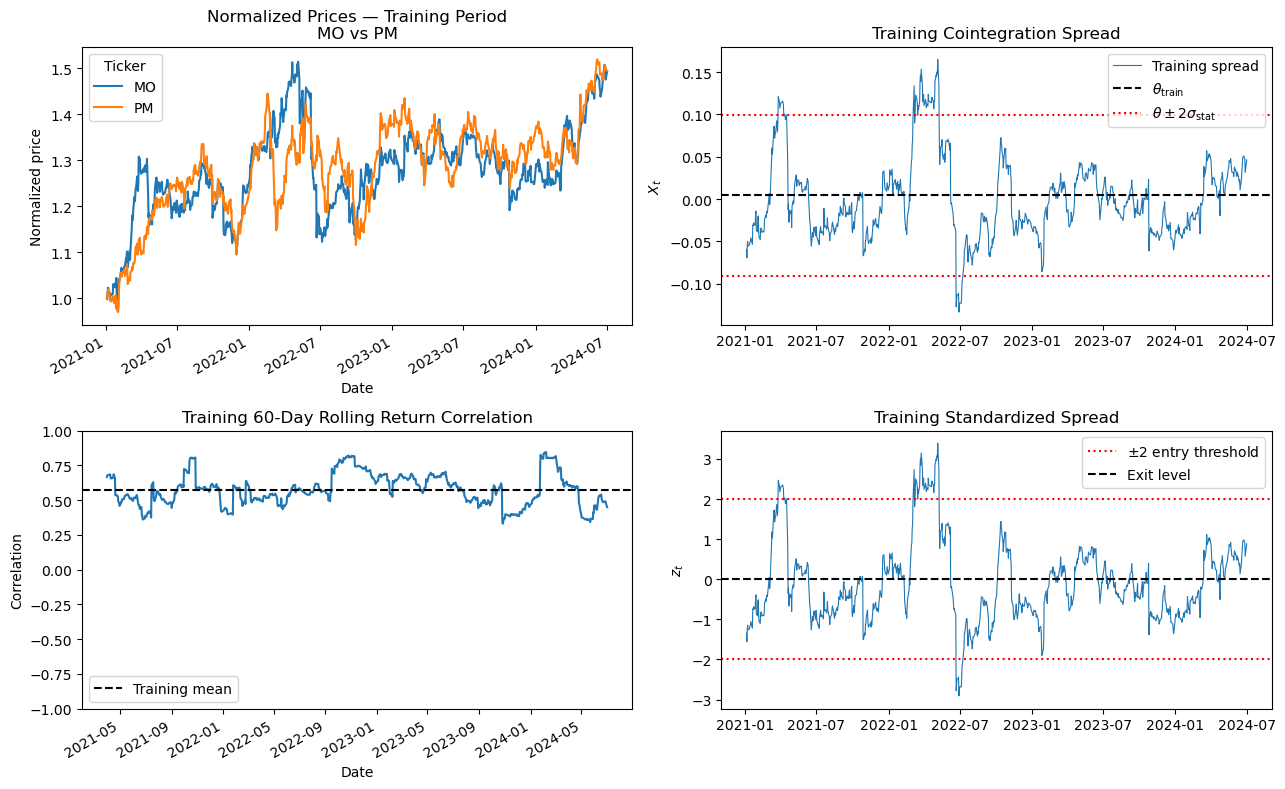

In [ ]:
# Training-period diagnostics
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

(prices_train / prices_train.iloc[0]).plot(
    ax=axes[0, 0],
    title=f"Normalized Prices — Training Period\n{TICKERS[0]} vs {TICKERS[1]}")
axes[0, 0].set_ylabel("Normalized price")

axes[0, 1].plot(spread_train.index, spread_train.values, lw=0.8,
                label="Training spread")
axes[0, 1].axhline(ou_train["theta"], color="black", linestyle="--",
                   label=r"$\theta_{\mathrm{train}}$")
for s in (+2, -2):
    axes[0, 1].axhline(ou_train["theta"] + s * ou_train["sigma_stationary"],
                       color="red", linestyle=":",
                       label=r"$\theta \pm 2\sigma_{\mathrm{stat}}$" if s > 0 else None)
axes[0, 1].set_title("Training Cointegration Spread")
axes[0, 1].set_ylabel(r"$X_t$")
axes[0, 1].legend()

logret_train = np.log(prices_train).diff().dropna()
rc = logret_train[TICKERS[0]].rolling(60).corr(logret_train[TICKERS[1]])
rc.plot(ax=axes[1, 0], title="Training 60-Day Rolling Return Correlation")
axes[1, 0].axhline(rc.mean(), color="black", linestyle="--", label="Training mean")
axes[1, 0].set_ylim(-1, 1)
axes[1, 0].set_ylabel("Correlation")
axes[1, 0].legend()

z_train = (spread_train - ou_train["theta"]) / ou_train["sigma_stationary"]
axes[1, 1].plot(z_train.index, z_train.values, lw=0.8)
for level in (Z_ENTRY, -Z_ENTRY):
    axes[1, 1].axhline(level, color="red", linestyle=":",
                       label=r"$\pm2$ entry threshold" if level > 0 else None)
axes[1, 1].axhline(Z_EXIT, color="black", linestyle="--", label="Exit level")
axes[1, 1].set_title("Training Standardized Spread")
axes[1, 1].set_ylabel(r"$z_t$")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 1.4 Parameter stability within the training window

Freezing parameters for the whole test period is only defensible if
$\hat\beta$ and the half-life are stable within the training window. We check
expanding windows and late sub-windows (does the recent relationship look like the full-sample
one?).

The short sub-windows have very low unit-root test power, so their p-values are expected to be above 0.05. What we need is that the hedge ratio and the mean-reversion speed do not drift wildly. A large swing in
$\hat\beta$ would undermine the frozen-parameter design of the backtest and would have to be reported as a risk.


In [49]:
TRAIN_STABILITY_WINDOWS = {
    # expanding
    "2021-2022 (expanding)": ("2021-01-01", "2022-12-31"),
    "2021-2023 (expanding)": ("2021-01-01", "2023-12-31"),
    "2021-2024H1 (full train)": ("2021-01-01", TRAIN_END),
    # late sub-windows
    "2022-2024H1 (late)": ("2022-01-01", TRAIN_END),
    "2023-2024H1 (late)": ("2023-01-01", TRAIN_END),
}

stability_rows = []
t1, t2 = TICKERS
for name, (ws, we) in TRAIN_STABILITY_WINDOWS.items():
    wp = raw_train.loc[ws:we, [t1, t2]].dropna(how="any")
    beta_w, alpha_w, spread_w, tests_w = engle_granger(
        np.log(wp[t1]), np.log(wp[t2]))
    try:
        hl_w = fit_ou(spread_w)["half_life_days"]
    except ValueError:
        hl_w = np.nan
    # asymmetry cross-check: reversed regression ordering
    _, _, _, tests_r = engle_granger(np.log(wp[t2]), np.log(wp[t1]))
    stability_rows.append(dict(window=name, n_obs=len(wp), beta=beta_w,
                               EG_p=tests_w["eg_pvalue"],
                               EG_p_reversed=tests_r["eg_pvalue"],
                               half_life_days=hl_w))

stability_table = pd.DataFrame(stability_rows)
display(stability_table.round(4))

b_rng = stability_table["beta"].max() - stability_table["beta"].min()
print(f"beta range across windows: {b_rng:.3f} "
      f"(full-train beta = {beta:.3f})")


,window,n_obs,beta,EG_p,EG_p_reversed,half_life_days
0,2021-2022 (expanding),503,0.7362,0.0974,0.3138,29.4182
1,2021-2023 (expanding),753,0.6965,0.0363,0.1150,26.0796
2,2021-2024H1 (full train),878,0.7354,0.0151,0.0381,25.1859
3,2022-2024H1 (late),626,0.6558,0.2115,0.0134,29.2578
4,2023-2024H1 (late),375,0.8625,0.0594,0.0376,12.1489


beta range across windows: 0.207 (full-train beta = 0.735)


## 1.5 Out-of-sample signals
The test spread is constructed with the *training* $(\alpha, \beta)$ and
standardized with the *training* $(\theta, \sigma_{\text{stat}})$. Nothing is
re-estimated. Signals: enter at $|z| > 2$, exit at $z = 0$ or after
$2\times$ half-life.


In [50]:
spread_test = (np.log(prices_test[TICKERS[0]])
               - alpha
               - beta * np.log(prices_test[TICKERS[1]]))
spread_test.name = "test_spread"

z_test = (spread_test - ou_train["theta"]) / ou_train["sigma_stationary"]

trades = generate_signals(spread=spread_test, ou=ou_train,
                          z_entry=Z_ENTRY, z_exit=Z_EXIT, max_hold=MAX_HOLD)
print(f"{len(trades)} trades in the test window "
      f"({prices_test.index[0].date()} to {prices_test.index[-1].date()}):")
display(trades)


4 trades in the test window (2024-07-02 to 2026-06-30):


,entry_date,exit_date,direction,z_at_entry,z_at_exit
0,2025-06-04,2025-07-24,1,-2.041870,0.092796
1,2025-08-27,2025-11-06,-1,2.076942,0.557466
2,2026-03-03,2026-05-13,-1,2.038456,2.200972
3,2026-05-14,2026-06-30,-1,2.133186,3.096410


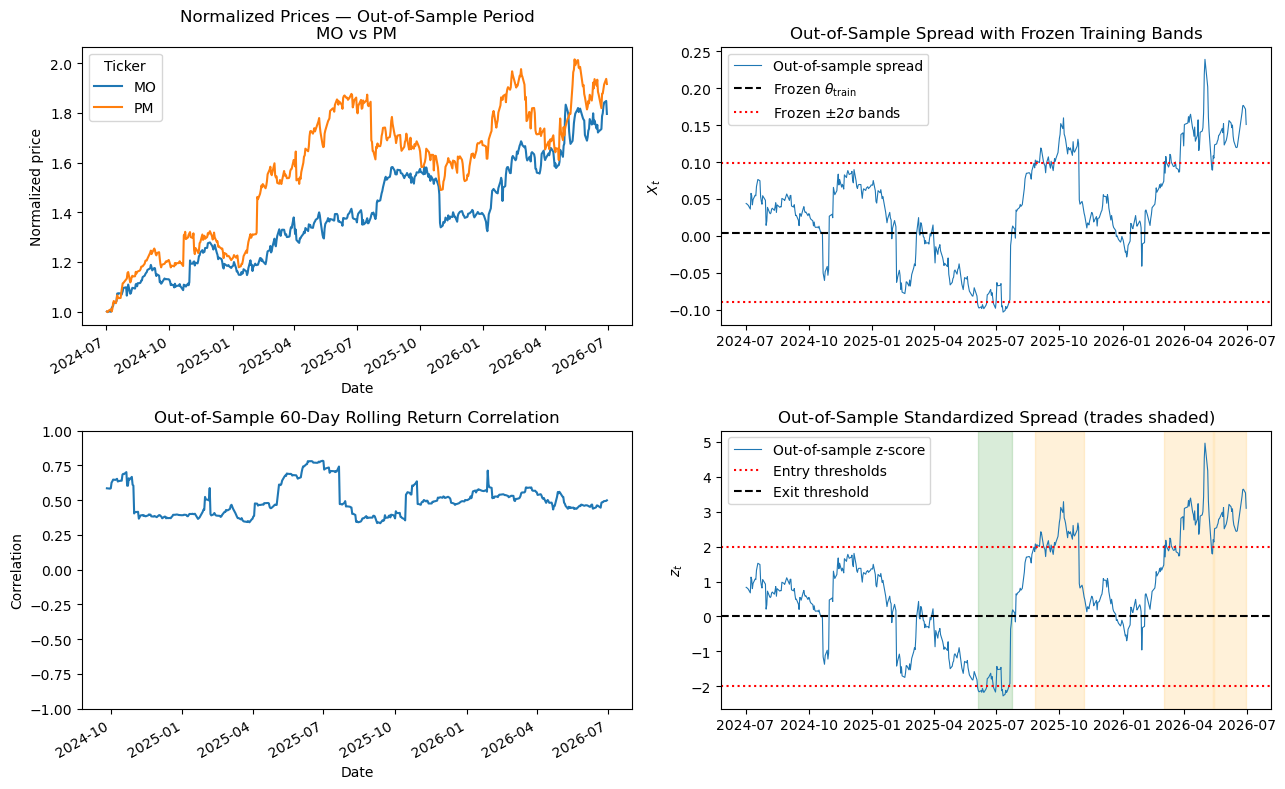

In [51]:
# Out-of-sample diagnostics
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

(prices_test / prices_test.iloc[0]).plot(
    ax=axes[0, 0],
    title=f"Normalized Prices — Out-of-Sample Period\n{TICKERS[0]} vs {TICKERS[1]}")
axes[0, 0].set_ylabel("Normalized price")

axes[0, 1].plot(spread_test.index, spread_test.values, lw=0.8,
                label="Out-of-sample spread")
axes[0, 1].axhline(ou_train["theta"], color="black", linestyle="--",
                   label=r"Frozen $\theta_{\mathrm{train}}$")
for s in (+2, -2):
    axes[0, 1].axhline(ou_train["theta"] + s * ou_train["sigma_stationary"],
                       color="red", linestyle=":",
                       label=r"Frozen $\pm2\sigma$ bands" if s > 0 else None)
axes[0, 1].set_title("Out-of-Sample Spread with Frozen Training Bands")
axes[0, 1].set_ylabel(r"$X_t$")
axes[0, 1].legend()

logret_test = np.log(prices_test).diff().dropna()
rc_test = logret_test[TICKERS[0]].rolling(60).corr(logret_test[TICKERS[1]])
rc_test.plot(ax=axes[1, 0], title="Out-of-Sample 60-Day Rolling Return Correlation")
axes[1, 0].set_ylim(-1, 1)
axes[1, 0].set_ylabel("Correlation")

axes[1, 1].plot(z_test.index, z_test.values, lw=0.8, label="Out-of-sample z-score")
axes[1, 1].axhline(Z_ENTRY, color="red", linestyle=":", label="Entry thresholds")
axes[1, 1].axhline(-Z_ENTRY, color="red", linestyle=":")
axes[1, 1].axhline(Z_EXIT, color="black", linestyle="--", label="Exit threshold")
# mark trade entries/exits
for _, tr in trades.iterrows():
    axes[1, 1].axvspan(tr.entry_date, tr.exit_date, alpha=0.15,
                       color="green" if tr.direction == 1 else "orange")
axes[1, 1].set_title("Out-of-Sample Standardized Spread (trades shaded)")
axes[1, 1].set_ylabel(r"$z_t$")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


Compare `z_at_entry` and
`z_at_exit` per trade. Exits at $z \approx 0$ are the mean-reversion the
strategy bets on. Exits with $|z_{\text{exit}}| \geq |z_{\text{entry}}|$ mean
the spread *kept diverging* and the trade was closed by the max-holding rule
(or by the end of the data).


In [52]:
# Question: with parameters frozen from training, does the relationship still
# look mean-reverting out of sample?

eg_stat_te, eg_p_te, _ = coint(np.log(prices_test[TICKERS[0]]),
                               np.log(prices_test[TICKERS[1]]))
print(f"EG test re-run on TEST window (diagnostic): p = {eg_p_te:.4f} "
      f"(low power on a short window; direction of evidence only)")

try:
    ou_test_diag = fit_ou(spread_test)   # OU refit on the FROZEN-beta test spread
    print(f"OU refit on frozen test spread (diagnostic): "
          f"half-life = {ou_test_diag['half_life_days']:.1f}d "
          f"(train: {ou_train['half_life_days']:.1f}d)")
except ValueError as e:
    print(f"OU refit on frozen test spread (diagnostic): NOT mean-reverting "
          f"in the test window ({e})")

drift = (spread_test.mean() - ou_train["theta"]) / ou_train["sigma_stationary"]
print(f"Mean of test spread vs frozen theta: {drift:+.2f} stationary sigmas")

s1_te, s2_te, rho_te = estimate_gbm_params(prices_test)
print(f"Test-window GBM (diagnostic): sigma1 = {s1_te:.4f} (train {sigma1_tr:.4f}), "
      f"sigma2 = {s2_te:.4f} (train {sigma2_tr:.4f}), "
      f"rho = {rho_te:.4f} (train {rho_tr:.4f})")


EG test re-run on TEST window (diagnostic): p = 0.6252 (low power on a short window; direction of evidence only)
OU refit on frozen test spread (diagnostic): half-life = 46.1d (train: 25.2d)
Mean of test spread vs frozen theta: +0.74 stationary sigmas
Test-window GBM (diagnostic): sigma1 = 0.2136 (train 0.2091), sigma2 = 0.2673 (train 0.1946), rho = 0.4909 (train 0.5608)


In [53]:
# Final training-parameter summary
summary = pd.DataFrame(
    {"value": [beta, alpha,
               tests_train["eg_stat"], tests_train["eg_pvalue"],
               tests_train["adf_stat"], tests_train["adf_pvalue"],
               ou_train["kappa"], ou_train["theta"], ou_train["sigma_X"],
               ou_train["half_life_days"], ou_train["sigma_stationary"],
               sigma1_tr, sigma2_tr, rho_tr, S1_0, S2_0]},
    index=["beta (log hedge ratio)", "alpha",
           "EG stat (train)", "EG p-value (train)",
           "ADF stat (cross-check)", "ADF p-value (cross-check)",
           "kappa (annualized)", "theta", "sigma_X (annualized)",
           "half-life (days)", "sigma_stationary",
           f"sigma_{TICKERS[0]} (train)", f"sigma_{TICKERS[1]} (train)",
           "rho (train)",
           f"S1_0 = {TICKERS[0]} at train end", f"S2_0 = {TICKERS[1]} at train end"],
).round(4)

summary


,value
beta (log hedge ratio),0.7354
alpha,0.3025
EG stat (train),-3.7642
EG p-value (train),0.0151
ADF stat (cross-check),-3.7621
ADF p-value (cross-check),0.0033
kappa (annualized),6.9353
theta,0.0044
sigma_X (annualized),0.1764
half-life (days),25.1859


## 1.6 Parameter block for next notebooks

Notebooks 02–05 are self-contained: each starts from the block printed below
(copy-paste it into their first code cell).


In [54]:
h_ratio = beta * S1_0 / S2_0   # local dollar hedge ratio at train end

print(f"""# Calibrated in 01_pair_selection.ipynb — train {DATA_START} -> {TRAIN_END}
TICKERS = ("{TICKERS[0]}", "{TICKERS[1]}")
DATA_START, DATA_END = "{DATA_START}", "{DATA_END}"
TRAIN_END = "{TRAIN_END}"
TRADING_DAYS, r_f = 252, {r_f}

# Cointegration / OU (training window)
BETA, ALPHA = {beta:.6f}, {alpha:.6f}
KAPPA, THETA = {ou_train["kappa"]:.6f}, {ou_train["theta"]:.6f}
SIGMA_X, SIGMA_STAT = {ou_train["sigma_X"]:.6f}, {ou_train["sigma_stationary"]:.6f}
HALF_LIFE_DAYS = {ou_train["half_life_days"]:.4f}
MAX_HOLD, T_OPT = {MAX_HOLD}, {T_OPT:.6f}
Z_ENTRY, Z_EXIT = {Z_ENTRY}, {Z_EXIT}

# GBM (training window)
SIGMA1, SIGMA2, RHO = {sigma1_tr:.6f}, {sigma2_tr:.6f}, {rho_tr:.6f}

# Prices at end of training (pricing anchor for notebooks 02-04)
S1_0, S2_0 = {S1_0:.4f}, {S2_0:.4f}
H_RATIO = {h_ratio:.6f}          # = BETA * S1_0 / S2_0; weight on leg 2
""")

# Calibrated in 01_pair_selection.ipynb — train 2021-01-01 -> 2024-07-01
TICKERS = ("MO", "PM")
DATA_START, DATA_END = "2021-01-01", "2026-07-01"
TRAIN_END = "2024-07-01"
TRADING_DAYS, r_f = 252, 0.04

# Cointegration / OU (training window)
BETA, ALPHA = 0.735372, 0.302487
KAPPA, THETA = 6.935343, 0.004386
SIGMA_X, SIGMA_STAT = 0.176370, 0.047356
HALF_LIFE_DAYS = 25.1859
MAX_HOLD, T_OPT = 50, 0.198413
Z_ENTRY, Z_EXIT = 2.0, 0.0

# GBM (training window)
SIGMA1, SIGMA2, RHO = 0.209149, 0.194566, 0.560770

# Prices at end of training (pricing anchor for notebooks 02-04)
S1_0, S2_0 = 40.0410, 94.0219
H_RATIO = 0.313172          # = BETA * S1_0 / S2_0; weight on leg 2

